In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving combined_final_with_lags.csv to combined_final_with_lags.csv


In [3]:
df = pd.read_csv("combined_final_with_lags.csv")

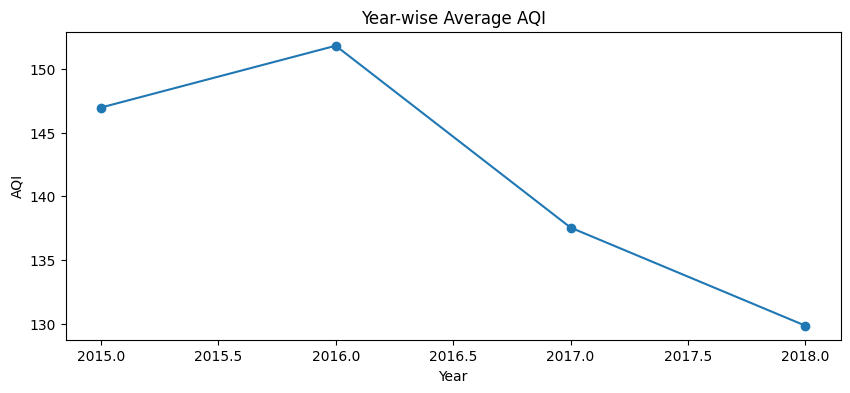

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(10,4))
df.groupby("Year")["avg_AQI"].mean().plot(marker="o")
plt.title("Year-wise Average AQI")
plt.ylabel("AQI")
plt.show()

In [5]:
df.columns

Index(['Year', 'Month', 'avg_PM25', 'avg_PM10', 'avg_NO2', 'avg_SO2', 'avg_CO',
       'avg_O3', 'avg_AQI', 'max_AQI', 'std_PM25', 'Day', 'Night',
       'Season_Post-Monsoon', 'Season_Summer', 'Season_Winter', 'avg_AQI_lag1',
       'avg_AQI_lag2', 'avg_AQI_lag3', 'avg_PM25_lag1', 'avg_PM25_lag2',
       'avg_PM25_lag3', 'avg_PM10_lag1', 'avg_PM10_lag2', 'avg_PM10_lag3',
       'avg_NO2_lag1', 'avg_NO2_lag2', 'avg_NO2_lag3', 'Day_lag1', 'Day_lag2',
       'Day_lag3', 'Night_lag1', 'Night_lag2', 'Night_lag3', 'avg_AQI_roll3',
       'avg_AQI_roll6', 'avg_PM25_roll3', 'avg_PM25_roll6', 'Day_roll3',
       'Day_roll6', 'City_encoded'],
      dtype='object')

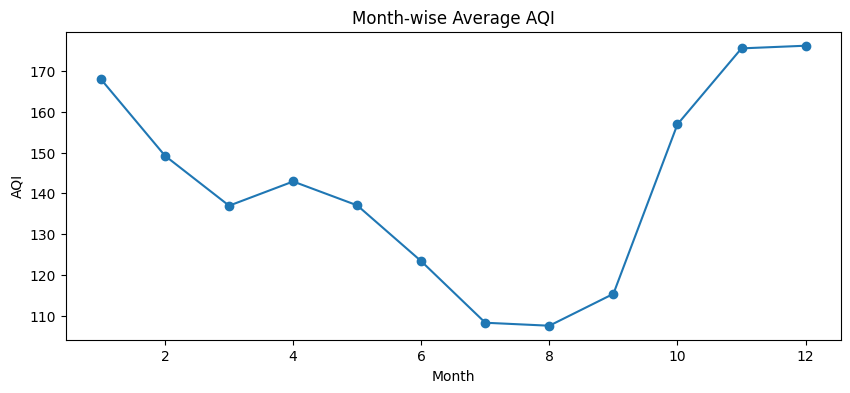

In [6]:
plt.figure(figsize=(10,4))
df.groupby("Month")["avg_AQI"].mean().plot(marker="o")
plt.title("Month-wise Average AQI")
plt.ylabel("AQI")
plt.show()

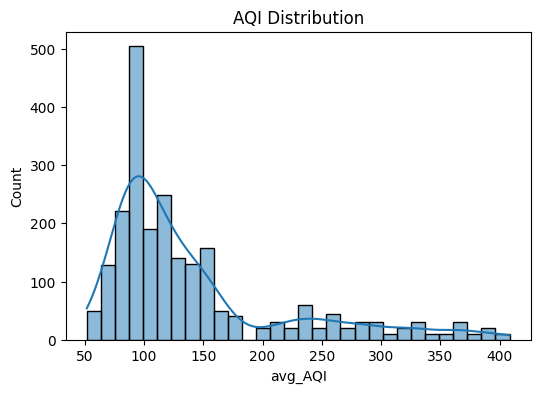

In [7]:
plt.figure(figsize=(6,4))
sns.histplot(df["avg_AQI"], bins=30, kde=True)
plt.title("AQI Distribution")
plt.show()

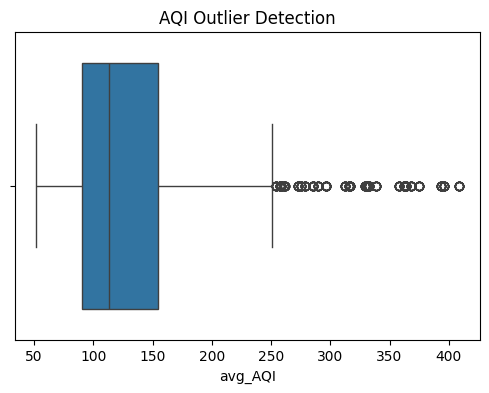

In [8]:
plt.figure(figsize=(6,4))
sns.boxplot(x=df["avg_AQI"])
plt.title("AQI Outlier Detection")
plt.show()

In [9]:
lag_cols = [col for col in df.columns if "lag" in col.lower()]
print("Lag Features:", lag_cols)


Lag Features: ['avg_AQI_lag1', 'avg_AQI_lag2', 'avg_AQI_lag3', 'avg_PM25_lag1', 'avg_PM25_lag2', 'avg_PM25_lag3', 'avg_PM10_lag1', 'avg_PM10_lag2', 'avg_PM10_lag3', 'avg_NO2_lag1', 'avg_NO2_lag2', 'avg_NO2_lag3', 'Day_lag1', 'Day_lag2', 'Day_lag3', 'Night_lag1', 'Night_lag2', 'Night_lag3']


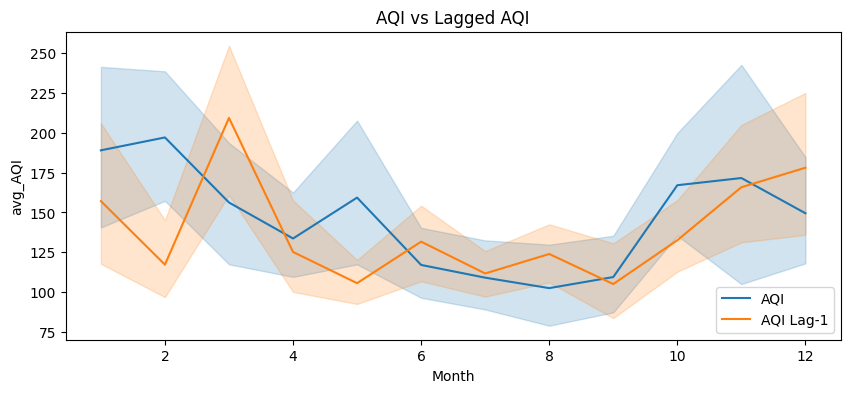

In [10]:
plt.figure(figsize=(10,4))
sns.lineplot(data=df.sample(200).sort_values("Month"), x="Month", y="avg_AQI", label="AQI")
sns.lineplot(data=df.sample(200).sort_values("Month"), x="Month", y="avg_AQI_lag1", label="AQI Lag-1")
plt.title("AQI vs Lagged AQI")
plt.show()


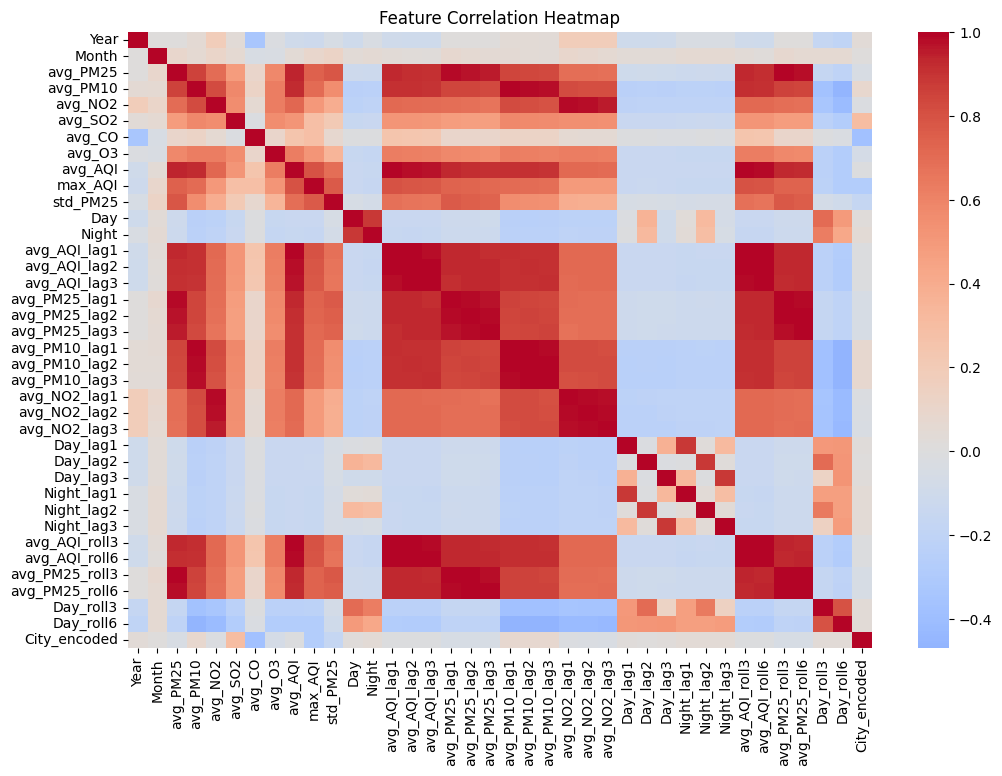

In [11]:
plt.figure(figsize=(12,8))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


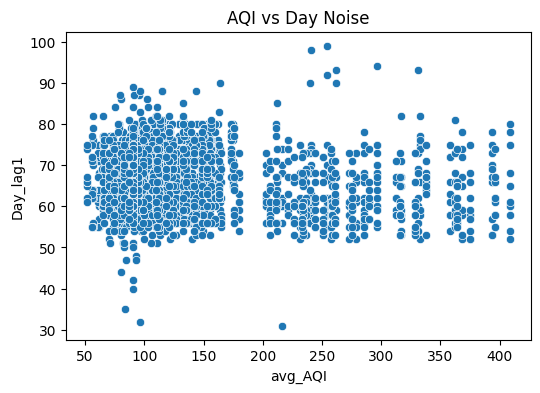

In [12]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["avg_AQI"], y=df["Day_lag1"])
plt.title("AQI vs Day Noise")
plt.show()

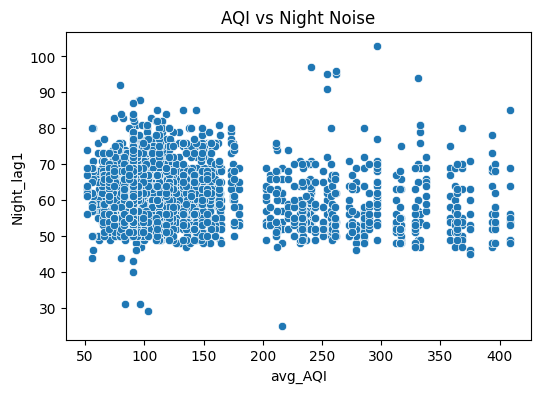

In [13]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=df["avg_AQI"], y=df["Night_lag1"])
plt.title("AQI vs Night Noise")
plt.show()

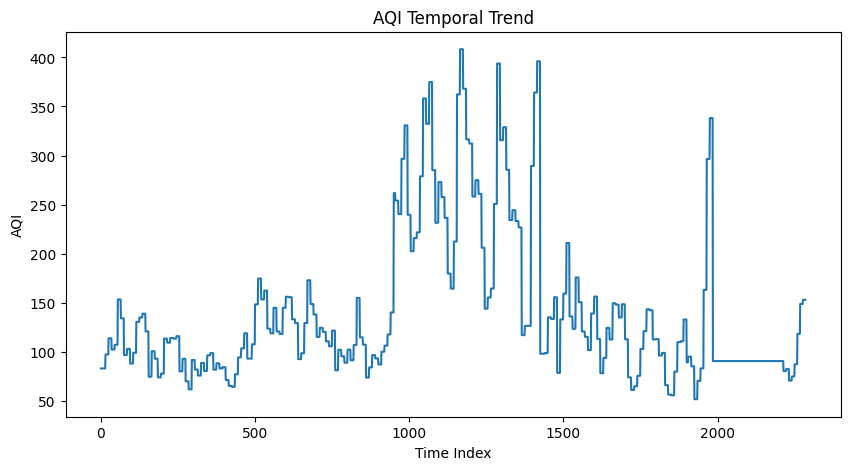

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(x=df.index, y=df["avg_AQI"])
plt.title("AQI Temporal Trend")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.show()

In [15]:
air_features = [c for c in df.columns if "PM" in c or "NO2" in c or "SO2" in c or "CO" in c or "O3" in c or "AQI" in c]
noise_features = [c for c in df.columns if "Day" in c or "Night" in c]
lag_features = [c for c in df.columns if "lag" in c.lower() or "roll" in c.lower()]
temporal_features = ["Year", "Month"]
spatial_features = ["City_encoded"]

print("\nAir Quality Features:", air_features)
print("\nNoise Features:", noise_features)
print("\nLag / Rolling Features:", lag_features)
print("\nTemporal Features:", temporal_features)
print("\nSpatial Features:", spatial_features)



Air Quality Features: ['avg_PM25', 'avg_PM10', 'avg_NO2', 'avg_SO2', 'avg_CO', 'avg_O3', 'avg_AQI', 'max_AQI', 'std_PM25', 'avg_AQI_lag1', 'avg_AQI_lag2', 'avg_AQI_lag3', 'avg_PM25_lag1', 'avg_PM25_lag2', 'avg_PM25_lag3', 'avg_PM10_lag1', 'avg_PM10_lag2', 'avg_PM10_lag3', 'avg_NO2_lag1', 'avg_NO2_lag2', 'avg_NO2_lag3', 'avg_AQI_roll3', 'avg_AQI_roll6', 'avg_PM25_roll3', 'avg_PM25_roll6']

Noise Features: ['Day', 'Night', 'Day_lag1', 'Day_lag2', 'Day_lag3', 'Night_lag1', 'Night_lag2', 'Night_lag3', 'Day_roll3', 'Day_roll6']

Lag / Rolling Features: ['avg_AQI_lag1', 'avg_AQI_lag2', 'avg_AQI_lag3', 'avg_PM25_lag1', 'avg_PM25_lag2', 'avg_PM25_lag3', 'avg_PM10_lag1', 'avg_PM10_lag2', 'avg_PM10_lag3', 'avg_NO2_lag1', 'avg_NO2_lag2', 'avg_NO2_lag3', 'Day_lag1', 'Day_lag2', 'Day_lag3', 'Night_lag1', 'Night_lag2', 'Night_lag3', 'avg_AQI_roll3', 'avg_AQI_roll6', 'avg_PM25_roll3', 'avg_PM25_roll6', 'Day_roll3', 'Day_roll6']

Temporal Features: ['Year', 'Month']

Spatial Features: ['City_encoded'

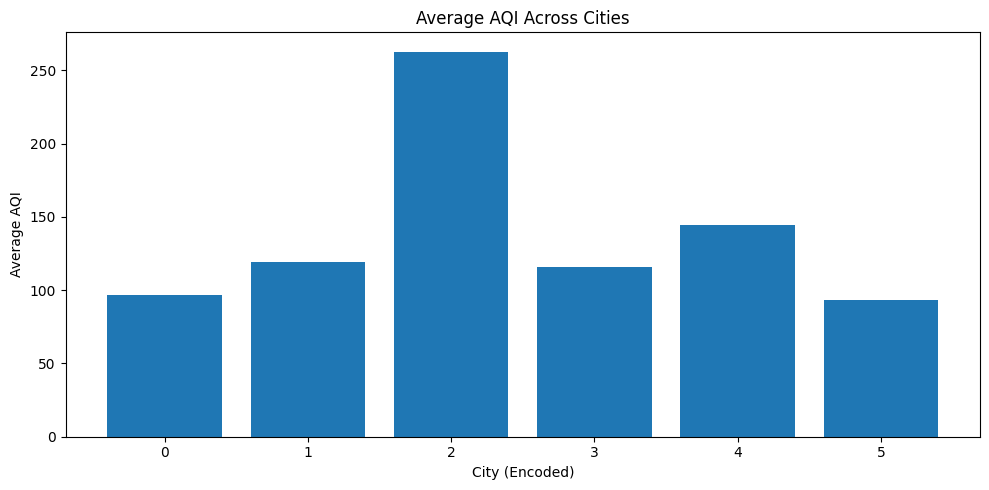

In [17]:
city_aqi = df.groupby("City_encoded")["avg_AQI"].mean().reset_index()
plt.figure(figsize=(10,5))
plt.bar(city_aqi["City_encoded"], city_aqi["avg_AQI"])
plt.xlabel("City (Encoded)")
plt.ylabel("Average AQI")
plt.title("Average AQI Across Cities")
plt.tight_layout()
plt.show()